# Baseline FULL — unigram+bigram at 700k / 1.5M / 3.6M

Extends the sample-size sweep in `present.ipynb` past 500k.

Only the winning configuration (unigram+bigram) is run. `C`, `MIN_DF`, `MAX_FEATURES`,
solver and seed are held at the baseline values, so sample size is the only variable.

One streaming pass over `train.csv` per size; only one size is held in memory at a time.
CPU only — sklearn has no GPU backend for these estimators.


## Setup

In [1]:
from pathlib import Path
import gc
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import joblib
from scipy import sparse

DATA_DIR = Path(r"C:\Users\bsarv\Fake Desktop\amz sentiment analysis\archive")
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

# Matrices, vectorisers and models are written here so nothing is vectorised twice.
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

COLUMN_NAMES = ["label", "title", "text"]

SEED = 42
CHUNK = 100_000
N_CHUNKS = 36
TOTAL_ROWS = 3_600_000

VAL_SIZE = 0.2
MIN_DF = 5
MAX_FEATURES = 50_000
NGRAM_RANGE = (1, 2)

# Set from the present.ipynb regularisation sweep (unigram+bigram row).
BEST_C = 2.5

SIZES = [700_000, 1_500_000, TOTAL_ROWS]

# unigram+bigram results already measured in present.ipynb, for the combined curve.
PRIOR = {
    20_000: 0.9056,
    40_000: 0.9063,
    80_000: 0.9170,
    160_000: 0.9234,
    400_000: 0.9291,
}


## 1. Sampling

`load_sample(n)` makes one pass over the file and takes `n / 2 / 36` rows of each class
from every chunk, so the sample is spread across the whole file rather than its opening rows.

At `n = TOTAL_ROWS` there is nothing to sample: the whole file is read as-is.

In [2]:
def load_sample(n):
    """One streaming pass -> (texts, labels) balanced across classes and chunks."""
    rng = np.random.default_rng(SEED)
    take = -(-(n // 2) // N_CHUNKS)      # rows per class per chunk (ceil)
    full = n >= TOTAL_ROWS
    parts = []

    t0 = time.perf_counter()

    for chunk in pd.read_csv(
        TRAIN_PATH,
        header=None,
        names=COLUMN_NAMES,
        dtype={"label": "int8"},
        keep_default_na=False,
        chunksize=CHUNK
    ):
        chunk["combined"] = (chunk["title"] + " " + chunk["text"]).str.strip()
        chunk = chunk[["label", "combined"]]

        if full:
            parts.append(chunk)
            continue

        for label in (1, 2):
            rows = chunk[chunk["label"] == label]
            parts.append(rows.sample(
                n=min(take, len(rows)),
                random_state=rng.integers(1e9)
            ))

    sample = pd.concat(parts, ignore_index=True)
    del parts
    gc.collect()

    if not full:
        sample = sample.groupby("label", group_keys=False).head(n // 2)

    sample = sample.sample(frac=1, random_state=SEED).reset_index(drop=True)

    read_seconds = time.perf_counter() - t0
    print(
        f"loaded {len(sample)} rows in {read_seconds:.1f}s  "
        f"balance={np.bincount(sample['label'].to_numpy())[1:]}  "
        f"memory={sample.memory_usage(deep=True).sum() / 1e6:.0f} MB"
    )

    texts = sample["combined"].tolist()
    labels = sample["label"].to_numpy()

    del sample
    gc.collect()

    return texts, labels


## 2. Runs

Same procedure per size: 80/20 stratified split, TF-IDF fitted on train only, one
logistic-regression fit at `BEST_C`. Everything for a size is freed before the next one starts.

In [3]:
results = []

for size in SIZES:
    print("=" * 60)
    print(f"size = {size}")
    print("=" * 60)

    texts, labels = load_sample(size)

    X_train, X_val, y_train, y_val = train_test_split(
        texts, labels,
        test_size=VAL_SIZE,
        random_state=SEED,
        stratify=labels
    )

    del texts, labels
    gc.collect()

    vec = TfidfVectorizer(
        ngram_range=NGRAM_RANGE,
        min_df=MIN_DF,
        max_features=MAX_FEATURES
    )

    t0 = time.perf_counter()
    Xtr = vec.fit_transform(X_train)     # fit ONLY on train
    Xva = vec.transform(X_val)           # val uses train's vocabulary
    vec_seconds = time.perf_counter() - t0

    # Saved before anything is freed. Reloading these costs seconds instead of
    # re-vectorising, which is the expensive half of the run.
    sparse.save_npz(ARTIFACT_DIR / f"Xtr_{size}.npz", Xtr)
    sparse.save_npz(ARTIFACT_DIR / f"Xva_{size}.npz", Xva)
    np.save(ARTIFACT_DIR / f"ytr_{size}.npy", y_train)
    np.save(ARTIFACT_DIR / f"yva_{size}.npy", y_val)
    joblib.dump(vec, ARTIFACT_DIR / f"vec_{size}.joblib")

    del X_train, X_val
    gc.collect()

    model = LogisticRegression(C=BEST_C, max_iter=1000, solver="liblinear")

    t0 = time.perf_counter()
    model.fit(Xtr, y_train)
    fit_seconds = time.perf_counter() - t0

    joblib.dump(model, ARTIFACT_DIR / f"model_{size}.joblib")

    pred = model.predict(Xva)

    results.append({
        "sample_size": size,
        "C": BEST_C,
        "train_rows": Xtr.shape[0],
        "features": "unigram+bigram",
        "vocab": Xtr.shape[1],
        "train_accuracy": accuracy_score(y_train, model.predict(Xtr)),
        "validation_accuracy": accuracy_score(y_val, pred),
        "validation_f1": f1_score(y_val, pred, pos_label=2),
        "iterations": model.n_iter_[0],
        "vectorize_seconds": round(vec_seconds, 1),
        "fit_seconds": round(fit_seconds, 1),
        "matrix_mb": round(
            (Xtr.data.nbytes + Xtr.indices.nbytes + Xtr.indptr.nbytes) / 1e6, 1
        ),
    })

    print(f"val={results[-1]['validation_accuracy']:.4f} "
          f"vocab={Xtr.shape[1]} vec={vec_seconds:.1f}s fit={fit_seconds:.1f}s "
          f"matrix={results[-1]['matrix_mb']:.0f} MB")

    print("\n", classification_report(
        y_val, pred, target_names=["negative", "positive"], digits=4
    ))

    print(pd.DataFrame(
        confusion_matrix(y_val, pred),
        index=["true neg", "true pos"],
        columns=["pred neg", "pred pos"]
    ), "\n")

    del Xtr, Xva, vec, model, pred, y_train, y_val
    gc.collect()

full_df = pd.DataFrame(results)
full_df.to_csv("baseline_full_results.csv", index=False)
full_df


size = 700000
loaded 700000 rows in 15.7s  balance=[350000 350000]  memory=337 MB
val=0.9327 vocab=50000 vec=125.0s fit=29.9s matrix=620 MB

               precision    recall  f1-score   support

    negative     0.9323    0.9332    0.9327     70000
    positive     0.9331    0.9322    0.9326     70000

    accuracy                         0.9327    140000
   macro avg     0.9327    0.9327    0.9327    140000
weighted avg     0.9327    0.9327    0.9327    140000

          pred neg  pred pos
true neg     65321      4679
true pos      4747     65253 

size = 1500000
loaded 1500000 rows in 16.0s  balance=[750000 750000]  memory=721 MB
val=0.9367 vocab=50000 vec=232.9s fit=86.9s matrix=1328 MB

               precision    recall  f1-score   support

    negative     0.9372    0.9363    0.9367    150000
    positive     0.9363    0.9372    0.9368    150000

    accuracy                         0.9367    300000
   macro avg     0.9367    0.9367    0.9367    300000
weighted avg     0.9367  

,sample_size,C,train_rows,features,vocab,train_accuracy,validation_accuracy,validation_f1,iterations,vectorize_seconds,fit_seconds,matrix_mb
0,700000,2.5,560000,unigram+bigram,50000,0.949139,0.932671,0.932639,7,125.0,29.9,620.3
1,1500000,2.5,1200000,unigram+bigram,50000,0.946827,0.936733,0.936764,8,232.9,86.9,1328.5
2,3600000,2.5,2880000,unigram+bigram,50000,0.945016,0.939650,0.939670,8,754.1,233.5,3186.9


## 3. Combined learning curve

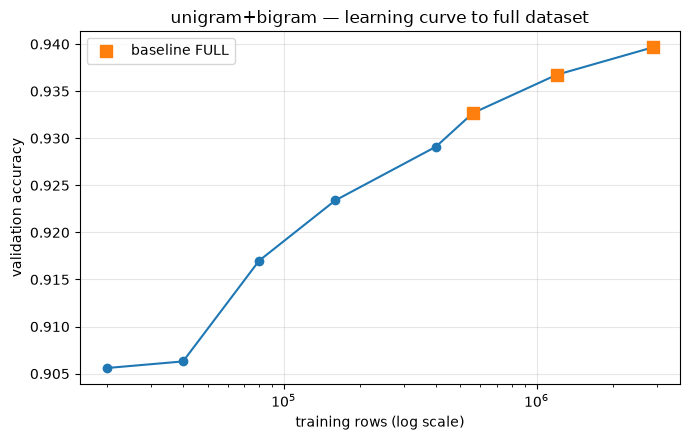

In [4]:
combined = pd.concat([
    pd.DataFrame({
        "train_rows": list(PRIOR.keys()),
        "validation_accuracy": list(PRIOR.values()),
        "source": "present.ipynb",
    }),
    full_df[["train_rows", "validation_accuracy"]].assign(source="baseline FULL"),
], ignore_index=True).sort_values("train_rows")

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(combined["train_rows"], combined["validation_accuracy"], marker="o", color="C0")

for src, marker in [("baseline FULL", "s")]:
    part = combined[combined["source"] == src]
    ax.scatter(part["train_rows"], part["validation_accuracy"],
               marker=marker, s=70, color="C1", zorder=3, label=src)

ax.set_xscale("log")
ax.set_xlabel("training rows (log scale)")
ax.set_ylabel("validation accuracy")
ax.set_title("unigram+bigram — learning curve to full dataset")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


In [5]:
# Marginal return per step up in training size.
prev = None

for rows, acc in zip(combined["train_rows"], combined["validation_accuracy"]):
    step = "" if prev is None else f"  ({(acc - prev) * 100:+.2f} pts)"
    print(f"  {rows:>9} rows  {acc:.4f}{step}")
    prev = acc


      20000 rows  0.9056
      40000 rows  0.9063  (+0.07 pts)
      80000 rows  0.9170  (+1.07 pts)
     160000 rows  0.9234  (+0.64 pts)
     400000 rows  0.9291  (+0.57 pts)
     560000 rows  0.9327  (+0.36 pts)
    1200000 rows  0.9367  (+0.41 pts)
    2880000 rows  0.9396  (+0.29 pts)


## 6. Reloading

Everything each size produced is on disk under `artifacts/`. Nothing above needs to run again.

`vectorize_seconds` is roughly three quarters of the cost of a size, so reloading the matrix
is what makes a second experiment at full scale affordable — a new `C` costs only the fit.

In [6]:
def load_artifacts(size):
    """Reload one size. Returns (vec, model, Xtr, Xva, y_train, y_val)."""
    return (
        joblib.load(ARTIFACT_DIR / f"vec_{size}.joblib"),
        joblib.load(ARTIFACT_DIR / f"model_{size}.joblib"),
        sparse.load_npz(ARTIFACT_DIR / f"Xtr_{size}.npz"),
        sparse.load_npz(ARTIFACT_DIR / f"Xva_{size}.npz"),
        np.load(ARTIFACT_DIR / f"ytr_{size}.npy"),
        np.load(ARTIFACT_DIR / f"yva_{size}.npy"),
    )


for f in sorted(ARTIFACT_DIR.iterdir()):
    print(f"{f.name:<28} {f.stat().st_size / 1e6:>8.1f} MB")


model_1500000.joblib              0.4 MB
model_3600000.joblib              0.4 MB
model_700000.joblib               0.4 MB
vec_1500000.joblib                1.9 MB
vec_3600000.joblib                1.9 MB
vec_700000.joblib                 1.9 MB
Xtr_1500000.npz                1064.1 MB
Xtr_3600000.npz                2554.6 MB
Xtr_700000.npz                  496.1 MB
Xva_1500000.npz                 260.9 MB
Xva_3600000.npz                 626.8 MB
Xva_700000.npz                  121.7 MB
ytr_1500000.npy                   1.2 MB
ytr_3600000.npy                   2.9 MB
ytr_700000.npy                    0.6 MB
yva_1500000.npy                   0.3 MB
yva_3600000.npy                   0.7 MB
yva_700000.npy                    0.1 MB


### Re-sweeping C at full size

`present.ipynb` swept `C` at 200,000 rows and held the winner fixed at every larger size.
That was a stated simplification: the optimum drifts with training size, and re-sweeping
would have meant re-vectorising each time.

With the matrix on disk that objection is gone — each extra `C` costs one fit.
Set `SWEEP_SIZE` and `SWEEP_C` and run.

In [7]:
SWEEP_SIZE = TOTAL_ROWS
SWEEP_C = [1.5, 2.0, 2.5, 3.0, 3.5]

_, _, Xtr, Xva, ytr, yva = load_artifacts(SWEEP_SIZE)
print(f"reloaded {Xtr.shape[0]} x {Xtr.shape[1]}")

sweep = []

for c_value in SWEEP_C:
    m = LogisticRegression(C=c_value, max_iter=1000, solver="liblinear")

    t0 = time.perf_counter()
    m.fit(Xtr, ytr)
    fit_seconds = time.perf_counter() - t0

    pred = m.predict(Xva)

    sweep.append({
        "C": c_value,
        "validation_accuracy": accuracy_score(yva, pred),
        "validation_f1": f1_score(yva, pred, pos_label=2),
        "fit_seconds": round(fit_seconds, 1),
    })

    print(f"C={c_value:<5} val={sweep[-1]['validation_accuracy']:.4f} "
          f"fit={fit_seconds:.1f}s")

    del m, pred
    gc.collect()

sweep_full_df = pd.DataFrame(sweep)
sweep_full_df.to_csv(f"sweep_C_{SWEEP_SIZE}.csv", index=False)
sweep_full_df


reloaded 2880000 x 50000
C=1.5   val=0.9394 fit=221.2s
C=2.0   val=0.9396 fit=241.8s
C=2.5   val=0.9396 fit=232.7s
C=3.0   val=0.9396 fit=247.7s
C=3.5   val=0.9396 fit=243.4s


,C,validation_accuracy,validation_f1,fit_seconds
0,1.5,0.939364,0.939380,221.2
1,2.0,0.939601,0.939622,241.8
2,2.5,0.939650,0.939670,232.7
3,3.0,0.939617,0.939638,247.7
4,3.5,0.939619,0.939640,243.4


## 7. Test set

Everything above is the validation split, which is drawn from the same pool as the training
rows. `test.csv` is a separate 400,000-row file (200k per class) that no model has seen.

Each size is scored with **its own** vectoriser — `transform` only, never a refit. Fitting the
vectoriser on the test set would leak it.

`val_minus_test` is the number to read. Close to zero means the validation curve was honest.
Consistently positive means validation was optimistic and the test column is what to report.

In [ ]:
test = pd.read_csv(
    TEST_PATH,
    header=None,
    names=COLUMN_NAMES,
    dtype={"label": "int8"},
    keep_default_na=False
)

test_texts = (test["title"] + " " + test["text"]).str.strip().tolist()
y_test = test["label"].to_numpy()

del test
gc.collect()

print(f"test: {len(y_test)} rows, balance={np.bincount(y_test)[1:]}")

test_rows = []

for size in SIZES:
    vec = joblib.load(ARTIFACT_DIR / f"vec_{size}.joblib")
    model = joblib.load(ARTIFACT_DIR / f"model_{size}.joblib")

    t0 = time.perf_counter()
    Xte = vec.transform(test_texts)          # transform only — never refit
    pred = model.predict(Xte)

    test_rows.append({
        "sample_size": size,
        "test_accuracy": accuracy_score(y_test, pred),
        "test_f1": f1_score(y_test, pred, pos_label=2),
        "seconds": round(time.perf_counter() - t0, 1),
    })

    print(f"{size:>9}  test={test_rows[-1]['test_accuracy']:.4f}  "
          f"({test_rows[-1]['seconds']:.1f}s)")

    if size == SIZES[-1]:
        print("\n", classification_report(
            y_test, pred, target_names=["negative", "positive"], digits=4
        ))
        print(pd.DataFrame(
            confusion_matrix(y_test, pred),
            index=["true neg", "true pos"],
            columns=["pred neg", "pred pos"]
        ))

    del vec, model, Xte, pred
    gc.collect()

test_df = pd.DataFrame(test_rows).merge(
    full_df[["sample_size", "validation_accuracy"]], on="sample_size"
)
test_df["val_minus_test"] = (
    test_df["validation_accuracy"] - test_df["test_accuracy"]
)

test_df.to_csv("baseline_full_test_results.csv", index=False)
test_df


test: 400000 rows, balance=[200000 200000]
   700000  test=0.9329  (31.9s)
  1500000  test=0.9363  (31.7s)
  3600000  test=0.9394  (31.9s)

               precision    recall  f1-score   support

    negative     0.9400    0.9386    0.9393    200000
    positive     0.9387    0.9401    0.9394    200000

    accuracy                         0.9394    400000
   macro avg     0.9394    0.9394    0.9394    400000
weighted avg     0.9394    0.9394    0.9394    400000

          pred neg  pred pos
true neg    187729     12271
true pos     11979    188021


,sample_size,test_accuracy,test_f1,seconds,validation_accuracy,val_minus_test
0,700000,0.932865,0.932912,31.9,0.932671,-0.000194
1,1500000,0.936268,0.936326,31.7,0.936733,0.000466
2,3600000,0.939375,0.939419,31.9,0.939650,0.000275


: 